In [1]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import re, warnings
warnings.filterwarnings("ignore")

# 固定随机种子
RANDOM_SEED = 42

# 输出文件夹
OUTPUT_DIR = Path("MAV551_ECA_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("输出文件夹: ", OUTPUT_DIR.resolve())

输出文件夹:  C:\Users\Ran\Desktop\MAV551\ECA\MAV551_ECA_output


In [2]:
# 绘图风格设置
sns.set_theme(style='whitegrid', font_scale=1.1)

# 字体与大小
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 13      # 图标题
plt.rcParams['axes.labelsize']   = 12      # 坐标轴标签
plt.rcParams['xtick.labelsize']  = 10      # x 轴刻度
plt.rcParams['ytick.labelsize']  = 10      # y 轴刻度
plt.rcParams['legend.fontsize']  = 10      # 图例
plt.rcParams['figure.titlesize'] = 15      # suptitle

# 图片尺寸与分辨率
plt.rcParams['figure.figsize']   = (10, 5)
plt.rcParams['figure.dpi']       = 120

# 保存图片的全局配置
plt.rcParams['savefig.dpi']      = 240         
plt.rcParams['savefig.bbox']     = 'tight'    


# 颜色（定义调色板，后续按需取用）
COLORS = {
    'primary'  : '#378ADD',   # 蓝，用于主要数值特征
    'secondary': '#1D9E75',   # 绿，用于类别特征
    'accent'   : '#D85A30',   # 橙红，用于对比/强调
    'neutral'  : '#888780',   # 灰，用于辅助元素
    'palette'  : ['#378ADD', '#1D9E75', '#D85A30',
                  '#BA7517', '#534AB7', '#888780']
}

import matplotlib.ticker as mticker
price_formatter = mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K')

### 1.数据预处理

In [3]:
# 1.1 读取数据，截取 2025年整年的数据
df = pd.read_csv('Resale flat prices based on registration date from Jan-2017 onwards.csv')

df['month'] = pd.to_datetime(df['month'])
df_2025 = df[df['month'].dt.year == 2025].copy()

print(f"筛选后的行数: {len(df_2025)}")
df_2025.sample(5)

筛选后的行数: 25086


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
215902,2025-03-01,TAMPINES,3 ROOM,438,TAMPINES ST 43,04 TO 06,74.0,Model A,1985,59 years 10 months,472000.0
215671,2025-08-01,TAMPINES,3 ROOM,869B,TAMPINES AVE 8,10 TO 12,67.0,Model A,2015,88 years 11 months,580000.0
202816,2025-08-01,CHOA CHU KANG,3 ROOM,818A,CHOA CHU KANG AVE 1,16 TO 18,67.0,Model A,2017,91 years 02 months,530000.0
214636,2025-08-01,SENGKANG,5 ROOM,309D,ANCHORVALE RD,16 TO 18,111.0,Premium Apartment,2002,76 years 04 months,692888.0
204408,2025-04-01,GEYLANG,3 ROOM,95,ALJUNIED CRES,01 TO 03,65.0,Improved,1975,49 years 05 months,398800.0


In [4]:
# 1.2 数据结构和基本信息统计
print(df_2025.shape) 
print(df_2025.dtypes)
print(df_2025.describe())
print(df_2025.nunique())   

(25086, 11)
month                  datetime64[ns]
town                           object
flat_type                      object
block                          object
street_name                    object
storey_range                   object
floor_area_sqm                float64
flat_model                     object
lease_commence_date             int64
remaining_lease                object
resale_price                  float64
dtype: object
                               month  floor_area_sqm  lease_commence_date  \
count                          25086    25086.000000         25086.000000   
mean   2025-06-09 12:14:24.482181376       94.890656          1998.340549   
min              2025-01-01 00:00:00       31.000000          1966.000000   
25%              2025-03-01 00:00:00       74.000000          1985.000000   
50%              2025-06-01 00:00:00       93.000000          1998.000000   
75%              2025-09-01 00:00:00      111.000000          2015.000000   
max              

In [5]:
# 1.3 缺失值检查
null_counts = df_2025.isnull().sum()

if null_counts.sum() > 0:
    print("发现以下列存在缺失值：")
    print(null_counts[null_counts > 0]) 
    print("\n--- 具体的缺失值行内容如下 ---")
    print(df_2025[df_2025.isnull().any(axis=1)].head(10)) 
else:
    print("数据中没有缺失值")

数据中没有缺失值


In [6]:
# 1.4 重复值检查（完全重复值删掉）
duplicate_count = df_2025.duplicated().sum()
print(f"重复行数: {duplicate_count}")

if duplicate_count > 0:
    print("--- 以下是部分重复的数据内容 ---")
    print(df_2025[df_2025.duplicated(keep=False)].sort_values(by=['month', 'block', 'street_name']).head(5))
    print("--------------------------------")
else:
    print("数据中没有重复值。")

df_2025 = df_2025.drop_duplicates().reset_index(drop=True)

print(f"删除后行数: {df_2025.shape[0]}")

重复行数: 13
--- 以下是部分重复的数据内容 ---
            month          town flat_type block     street_name storey_range  \
204726 2025-01-01       GEYLANG    4 ROOM   82B      CIRCUIT RD     19 TO 21   
204728 2025-01-01       GEYLANG    4 ROOM   82B      CIRCUIT RD     19 TO 21   
202661 2025-03-01  CENTRAL AREA    3 ROOM     4  TG PAGAR PLAZA     13 TO 15   
202662 2025-03-01  CENTRAL AREA    3 ROOM     4  TG PAGAR PLAZA     13 TO 15   
212619 2025-04-01     SEMBAWANG    4 ROOM  103B     CANBERRA ST     04 TO 06   

        floor_area_sqm flat_model  lease_commence_date     remaining_lease  \
204726            93.0    Model A                 2020  94 years 05 months   
204728            93.0    Model A                 2020  94 years 05 months   
202661            59.0   Improved                 1977            51 years   
202662            59.0   Improved                 1977            51 years   
212619            93.0    Model A                 2020  94 years 09 months   

        resale_price

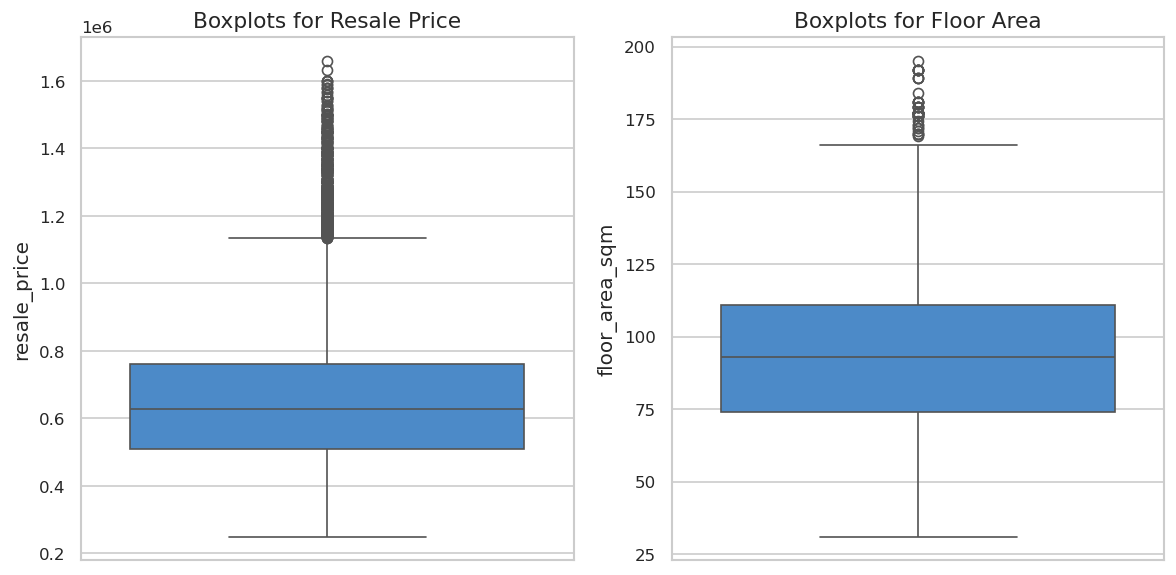

In [7]:
# 1.5 异常值检查
fig, axes = plt.subplots(1, 2)

sns.boxplot(data=df_2025, y="resale_price", ax=axes[0], color=COLORS['primary'])
axes[0].set_title("Boxplots for Resale Price")
sns.boxplot(data=df_2025, y="floor_area_sqm", ax=axes[1], color=COLORS['primary'])
axes[1].set_title("Boxplots for Floor Area")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'outlier_boxplots.png')
plt.show()

In [8]:
# 1.6 异常值统计与分析
Q1 = df_2025['resale_price'].quantile(0.25)
Q3 = df_2025['resale_price'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df_2025[df_2025['resale_price'] > upper_limit]
print(f"统计学上的高价异常值数量: {len(outliers)}")
print(f"异常值价格区间: {outliers['resale_price'].min()} 到 {outliers['resale_price'].max()}")
print(df_2025[df_2025['resale_price'] > 1135888.0]['town'].value_counts().head(5))

Q1 = df_2025['floor_area_sqm'].quantile(0.25)
Q3 = df_2025['floor_area_sqm'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df_2025[df_2025['floor_area_sqm'] > upper_limit]
print(f"统计学上的面积异常值数量: {len(outliers)}")
print(f"异常值面积区间: {outliers['floor_area_sqm'].min()} 到 {outliers['floor_area_sqm'].max()}")
print(df_2025[df_2025['floor_area_sqm'] >169.0]['town'].value_counts().head(5))

统计学上的高价异常值数量: 653
异常值价格区间: 1135888.0 到 1658888.0
town
TOA PAYOH          138
QUEENSTOWN          86
BUKIT MERAH         79
KALLANG/WHAMPOA     70
CLEMENTI            59
Name: count, dtype: int64
统计学上的面积异常值数量: 48
异常值面积区间: 169.0 到 195.0
town
WOODLANDS          38
YISHUN              7
JURONG EAST         1
KALLANG/WHAMPOA     1
Name: count, dtype: int64


统计学中的异常值，经核对发现这在房屋转售中是真实现象，保留有助于模型学习大面积房源、特殊地段的价格规律

In [9]:
# 1.7 特征数值化
# 将month转换为日期格式，并提取月份（1-12）
df_2025['month_num'] = df_2025['month'].dt.month

# 将flat_type数值化（线性回归用）────────────────────
flat_type_map = {
    '1 ROOM': 1, '2 ROOM': 2, '3 ROOM': 3,
    '4 ROOM': 4, '5 ROOM': 5,
    'EXECUTIVE': 6, 'MULTI-GENERATION': 7
}
df_2025['flat_type_num'] = df_2025['flat_type'].map(flat_type_map)

# 将storey_range取中值，进行数值化处理
def parse_storey(s):
    nums = re.findall(r"\d+", str(s))
    return (int(nums[0]) + int(nums[1])) / 2
df_2025["storey_mid"] = df_2025["storey_range"].apply(parse_storey)

# 将remaining_lease列转换为数值型（总年数）
def parse_lease(s):
    s = str(s)
    y = int(re.search(r"(\d+) year", s).group(1)) if "year" in s else 0
    m = int(re.search(r"(\d+) month", s).group(1)) if "month" in s else 0
    return y + m / 12
df_2025["remaining_lease"] = df_2025["remaining_lease"].apply(parse_lease)

df_2025.describe()

,month,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,month_num,flat_type_num,storey_mid
count,25073,25073.000000,25073.000000,25073.000000,2.507300e+04,25073.000000,25073.000000,25073.000000
mean,2025-06-09 12:08:24.829896448,94.896941,1998.332788,72.409973,6.524976e+05,6.270769,4.036174,8.871774
min,2025-01-01 00:00:00,31.000000,1966.000000,40.083333,2.500000e+05,1.000000,1.000000,2.000000
25%,2025-03-01 00:00:00,74.000000,1985.000000,59.166667,5.100000e+05,3.000000,3.000000,5.000000
50%,2025-06-01 00:00:00,93.000000,1998.000000,71.916667,6.280000e+05,6.000000,4.000000,8.000000
75%,2025-09-01 00:00:00,111.000000,2015.000000,88.916667,7.600000e+05,9.000000,5.000000,11.000000
max,2025-12-01 00:00:00,195.000000,2021.000000,95.333333,1.658888e+06,12.000000,7.000000,50.000000
std,NaN,23.863423,15.322630,15.367399,2.040676e+05,3.368713,0.918943,5.993078


### 2.特征可视化分析

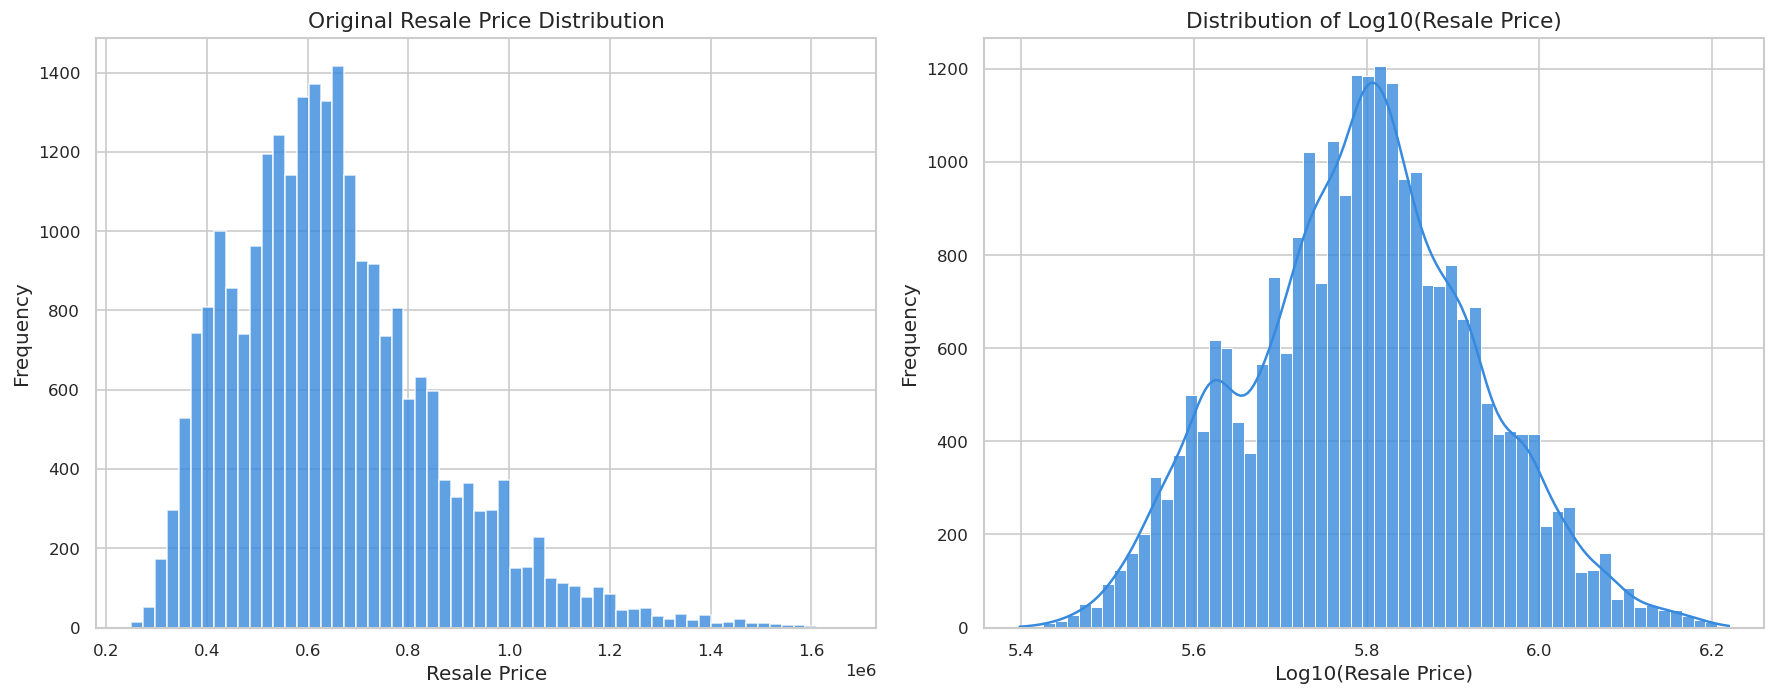

In [10]:
# 2.1 绘制转售价格分布图和对数变换后的分布图
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df_2025['resale_price'], bins=60, color=COLORS['primary'], alpha=0.8)
axes[0].set_title('Original Resale Price Distribution')
axes[0].set_xlabel('Resale Price')
axes[0].set_ylabel('Frequency')

sns.histplot(np.log10(df_2025["resale_price"]), kde=True, bins=60, 
             color=COLORS['primary'], alpha=0.8, edgecolor=None, ax=axes[1])
axes[1].set_title("Distribution of Log10(Resale Price)")
axes[1].set_xlabel("Log10(Resale Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resale_price_combined_comparison.png')
plt.show()

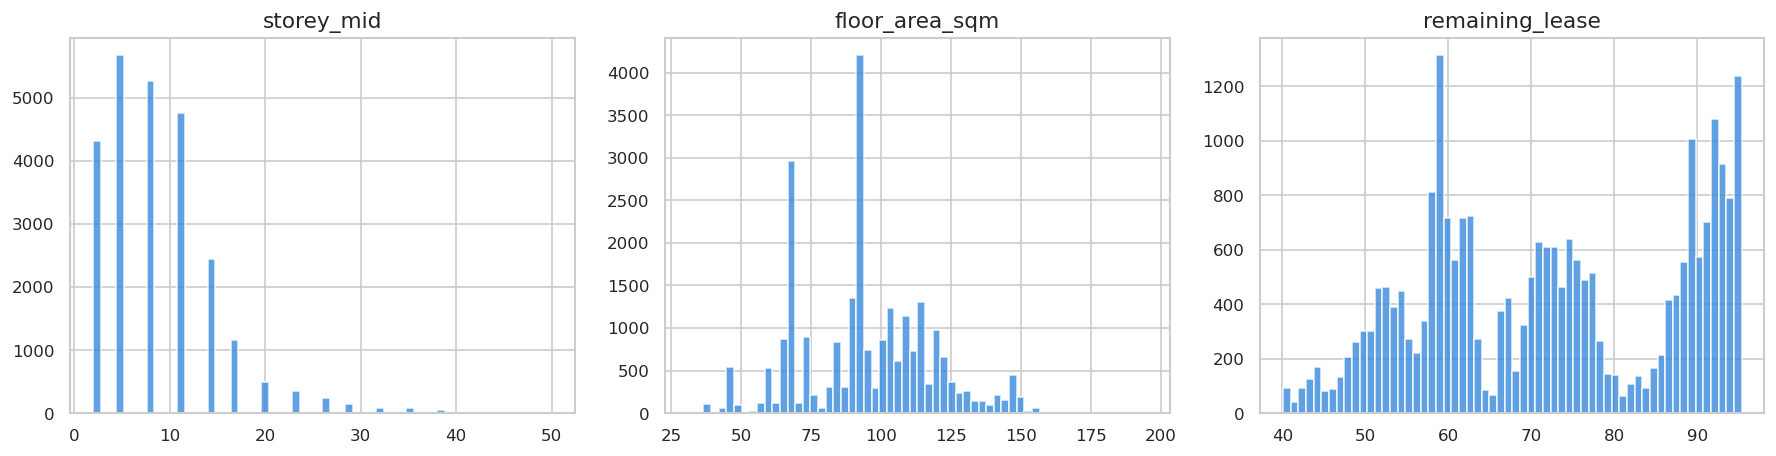

In [11]:
# 2.2 绘制数值变量直方图
fig, axes = plt.subplots(1, 3,figsize=(15, 4))
for ax, col in zip(axes, ['storey_mid','floor_area_sqm', 'remaining_lease']):
    ax.hist(df_2025[col], bins=60, color=COLORS['primary'],alpha=0.8)
    ax.set_title(col)

plt.savefig(OUTPUT_DIR / 'numerical_variables_histograms.png')
plt.tight_layout()
plt.show()

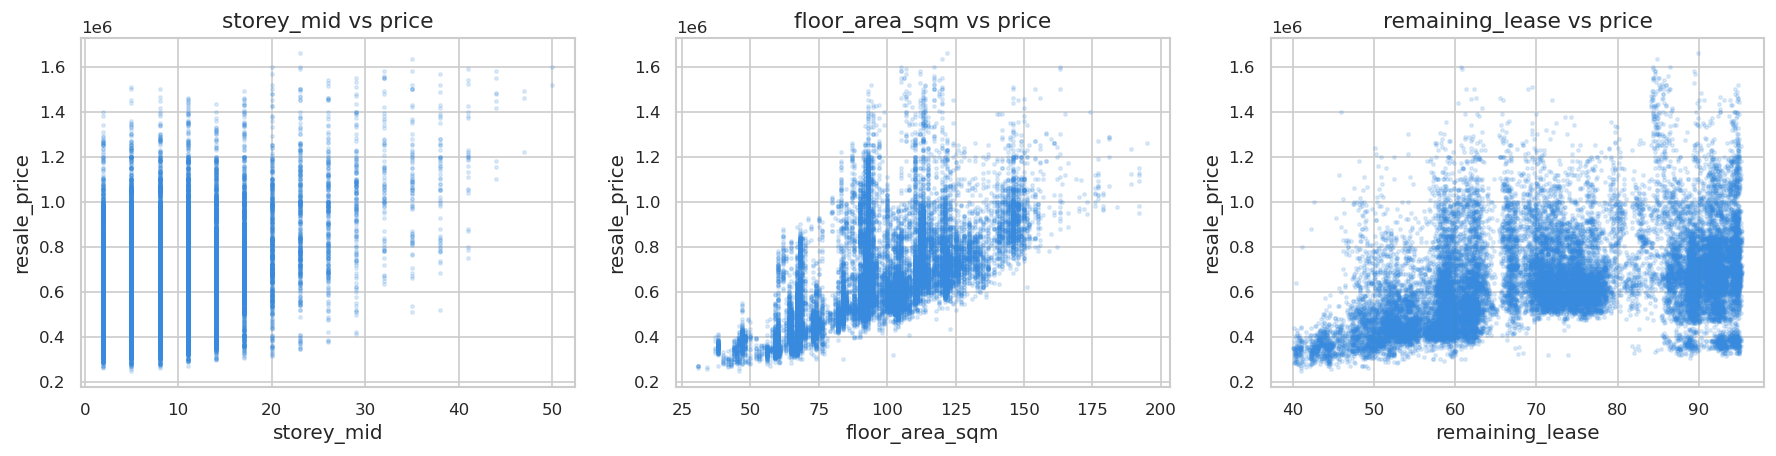

In [12]:
# 2.3 绘制散点图，查看数值特征与转售价格的关系
num_feats = ["storey_mid", "floor_area_sqm", "remaining_lease"]
fig, axes = plt.subplots(1, 3,figsize=(15,4))
for i, col in enumerate(num_feats):
    axes[i].scatter(df_2025[col], df_2025["resale_price"], alpha=0.15, s=4, color=COLORS['primary'])
    axes[i].set_xlabel(col); axes[i].set_ylabel("resale_price")
    axes[i].set_title(f"{col} vs price")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'numerical_features_vs_resale_price.png')
plt.show()

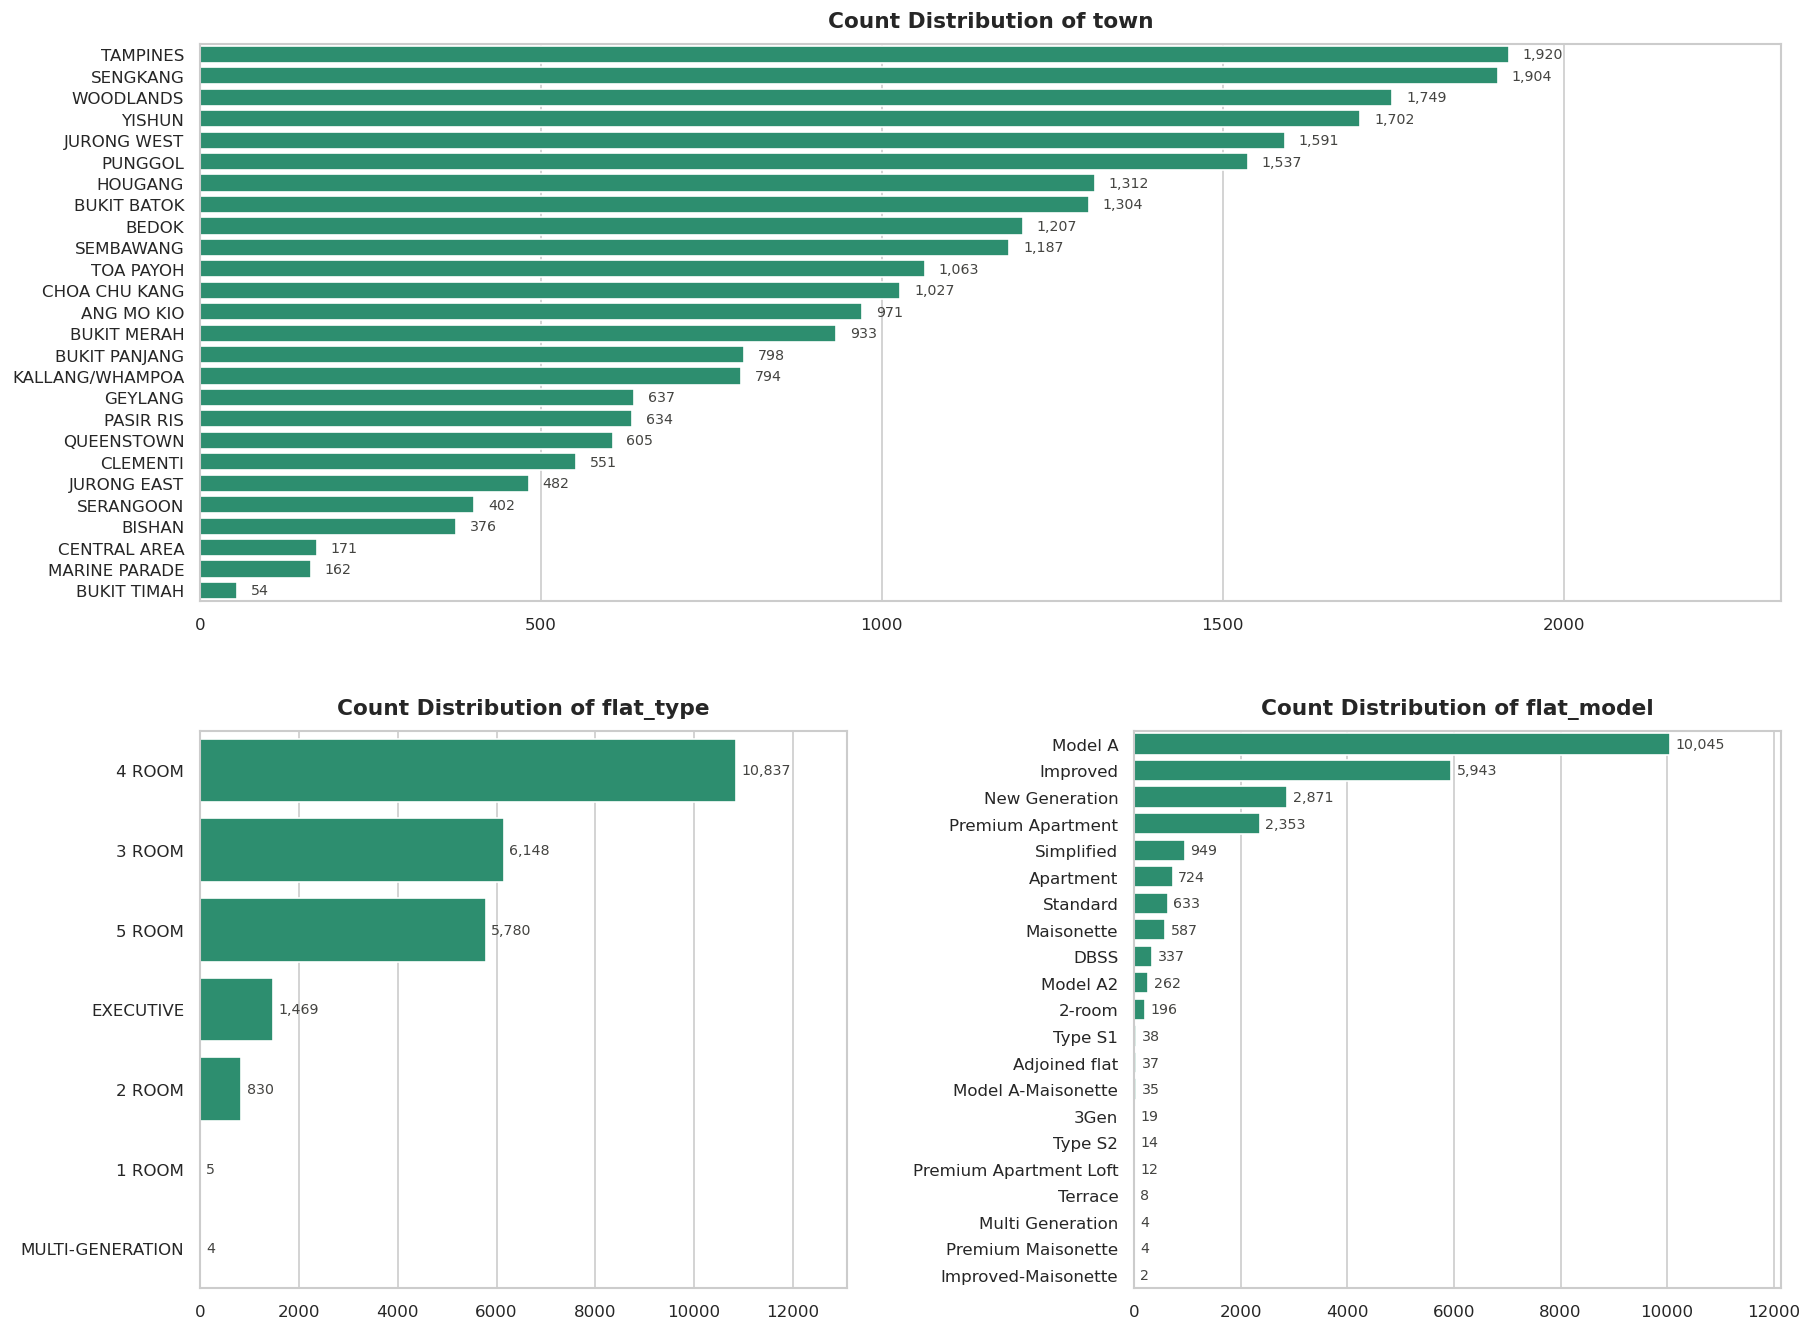

In [13]:
# 2.4 绘制类别变量直方图
cat_cols = ['town', 'flat_type', 'flat_model']

fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2) 
ax2 = plt.subplot2grid((2, 2), (1, 0))    
ax3 = plt.subplot2grid((2, 2), (1, 1)) 

axes = [ax1, ax2, ax3]

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df_2025[col].value_counts().index
    sns.countplot(data=df_2025, y=col, order=order, ax=ax, color=COLORS['secondary'])
    ax.set_title(f'Count Distribution of {col}', fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')  

    for patch in ax.patches:
        w = patch.get_width()
        if w > 0:
            ax.text(
                w + (ax.get_xlim()[1] * 0.01),                          
                patch.get_y() + patch.get_height() / 2,
                f'{int(w):,}',                  
                va='center', ha='left',
                fontsize=8.5, color='#444441'
            )

    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

plt.tight_layout(pad=3.0)
plt.savefig(OUTPUT_DIR / 'categorical_variables_histograms.png')
plt.show()

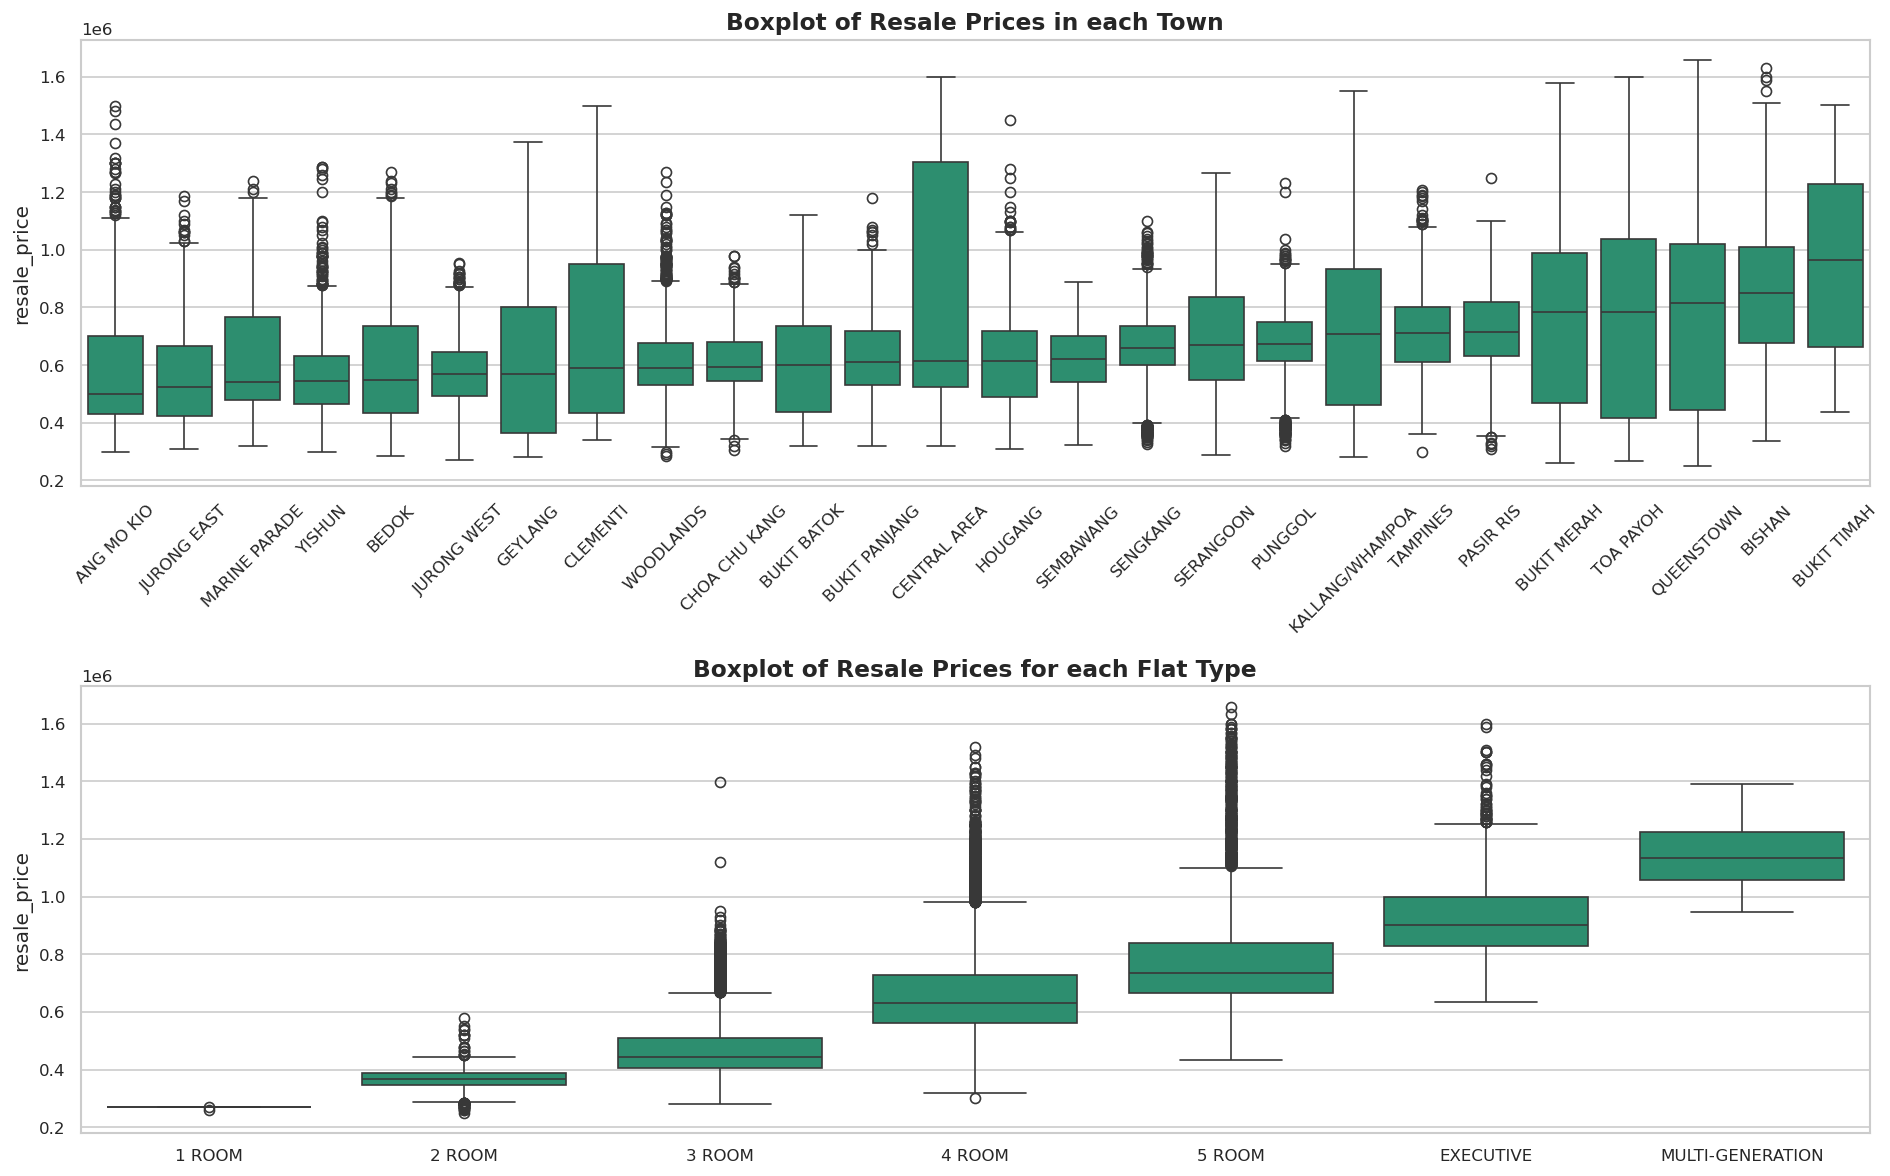

In [14]:
# 2.5 绘制箱线图，分别查看各地区、各房型的转售价格分布情况
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- 第一张子图：按地区 (town) ---
town_order = df_2025.groupby("town")["resale_price"].median().sort_values().index

sns.boxplot(
    data=df_2025, 
    x="town",
    y="resale_price", 
    order=town_order, 
    color=COLORS['secondary'], 
    ax=axes[0]  
)
axes[0].set_title("Boxplot of Resale Prices in each Town", fontsize=14,fontweight='bold')
axes[0].tick_params(axis='x', rotation=45) # 旋转x轴标签
axes[0].set_xlabel("") 

# --- 第二张子图：按房型 (flat_type) ---
type_order = df_2025.groupby("flat_type")["resale_price"].median().sort_values().index

sns.boxplot(
    data=df_2025, 
    x="flat_type",
    y="resale_price", 
    order=type_order,
    color=COLORS['secondary'], 
    ax=axes[1]  
)
axes[1].set_title("Boxplot of Resale Prices for each Flat Type", fontsize=14,fontweight='bold')
axes[1].set_xlabel("") 

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'categorical_variables_boxplots.png')
plt.show()

### 3.特征工程

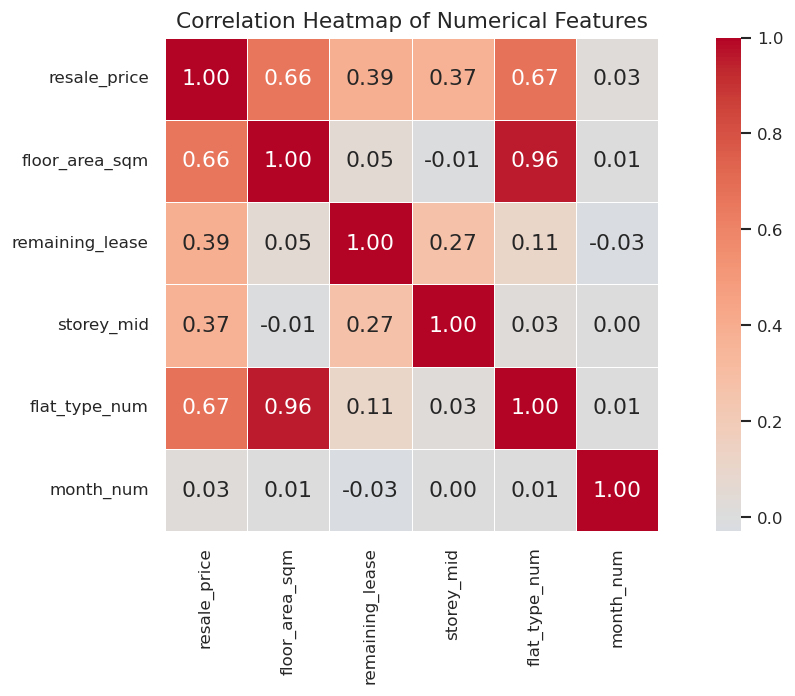

In [15]:
# 3.1 相关性分析
num_cols = ['resale_price', 'floor_area_sqm', 'remaining_lease',
            'storey_mid', 'flat_type_num', 'month_num']
corr = df_2025[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png')
plt.show()

In [16]:
# 3.2 计算VIF
# 建议先排除 resale_price，因为 VIF 只针对自变量
features = ['floor_area_sqm', 'remaining_lease', 'storey_mid', 'flat_type_num', 'month_num']
X = df_2025[features].copy()

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                   for i in range(X_with_const.shape[1])]

print(vif_data[vif_data["feature"] != 'const'].sort_values(by="VIF", ascending=False))

           feature        VIF
4    flat_type_num  12.537189
1   floor_area_sqm  12.433295
2  remaining_lease   1.119012
3       storey_mid   1.085327
5        month_num   1.001104


特征分析
1. floor_area_sqm和flat_type_num存在明显的共线性，在线性回归中剔除剔除flat_type_num，确保模型参数估计的稳定性和解释性；在树模型中保留flat_type以追求预测精度。
2. 剔除month_num，它与resale_price的相关性极低，仅为0.03。
3. block和street的类别非常多，并且与town存在信息重叠情况，为防止随机森林模型和梯度提升树模型过拟合，以及避免线性回归模型中出现“维度爆炸”问题，剔除block和street。
4. 最终进入模型的特征是floor_area_sqm，remaining_lease，storey_mid，flat_type，town，flat_model。

### 4.确定各模型特征策略+数据集切分

In [17]:
# 线性回归策略：去共线性 + 关键地理位置
LR_COLS = ['floor_area_sqm', 'remaining_lease', 'storey_mid', 'town'] 

# 树模型策略：全特征保留（除 month_num）
TREE_COLS = ['floor_area_sqm', 'remaining_lease', 'storey_mid', 'flat_type', 'town', 'flat_model']

# 数据集切分 
X = df_2025[list(set(LR_COLS + TREE_COLS))] 
y_raw = df_2025['resale_price']
y_log = np.log1p(y_raw)  

X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y_raw, test_size=0.2, random_state=RANDOM_SEED)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=RANDOM_SEED)

# 定义各模型具体的列清单 ---
LR_NUM = ['floor_area_sqm', 'remaining_lease', 'storey_mid']
LR_CAT = ['town']

RF_NUM = ['floor_area_sqm', 'remaining_lease', 'storey_mid']
RF_CAT = ['flat_type', 'town', 'flat_model']

GB_NUM = RF_NUM
GB_CAT = RF_CAT

print("特征集定义完毕")
print(f"  线性回归  数值特征: {LR_NUM}")
print(f"            类别特征: {LR_CAT}")
print(f"  随机森林  数值特征: {RF_NUM}")
print(f"            类别特征: {RF_CAT}")
print(f"  梯度提升树数值特征: {GB_NUM}")
print(f"            类别特征: {GB_CAT}")

特征集定义完毕
  线性回归  数值特征: ['floor_area_sqm', 'remaining_lease', 'storey_mid']
            类别特征: ['town']
  随机森林  数值特征: ['floor_area_sqm', 'remaining_lease', 'storey_mid']
            类别特征: ['flat_type', 'town', 'flat_model']
  梯度提升树数值特征: ['floor_area_sqm', 'remaining_lease', 'storey_mid']
            类别特征: ['flat_type', 'town', 'flat_model']


### 5.建模与验证

In [18]:
# 5.1 Pipeline 构建辅助函数
def make_pipeline(model, num_feats, cat_feats):
    transformers = [('num', StandardScaler(), num_feats)]
    if cat_feats:
        transformers.append((
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            cat_feats
        ))
    pre = ColumnTransformer(transformers=transformers)
    return Pipeline([('pre', pre), ('model', model)])

def get_X(split, num_feats, cat_feats):
    return split[num_feats + cat_feats]

In [19]:
# 5.2 定义交叉验证方案
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [20]:
# 5.3 线性回归模型
pipe_lr    = make_pipeline(LinearRegression(), LR_NUM, LR_CAT)
X_lr_train = get_X(X_train, LR_NUM, LR_CAT)

scores_lr = cross_val_score(
    pipe_lr, X_lr_train, y_train_log, cv=cv, scoring='r2'
)
print(f"Linear Regression  CV R²: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")

Linear Regression  CV R²: 0.8967 ± 0.0018


In [21]:
# 5.4 随机森林：GridSearchCV 超参数调优
X_rf_train = get_X(X_train, RF_NUM, RF_CAT)

pipe_rf = make_pipeline(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    RF_NUM, RF_CAT
)
param_grid_rf = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [None, 10, 20],
    'model__min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=cv, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_rf_train, y_train_raw)

print(f"Random Forest  最优参数 : {grid_rf.best_params_}")
print(f"Random Forest  最优 CV R²: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Random Forest  最优参数 : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Random Forest  最优 CV R²: 0.9493


In [22]:
# 5.5 梯度提升树：GridSearchCV 超参数调优 
X_xgb_train = get_X(X_train, GB_NUM, GB_CAT)

pipe_xgb = make_pipeline(
    XGBRegressor(
        random_state=RANDOM_SEED, 
        n_jobs=-1, 
        objective='reg:squarederror', 
        tree_method='hist'            
    ),
    GB_NUM, GB_CAT
)

param_grid_xgb = {
    'model__n_estimators' : [100, 200, 300],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth'    : [3, 5, 7],       
    'model__subsample'    : [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]    
}

grid_xgb = GridSearchCV(
    pipe_xgb, param_grid_xgb,
    cv=cv, scoring='r2', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_xgb_train, y_train_raw)

print(f"XGBoost  最优参数 : {grid_xgb.best_params_}")
print(f"XGBoost  最优 CV R2: {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost  最优参数 : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
XGBoost  最优 CV R2: 0.9573


### 6.结果分析

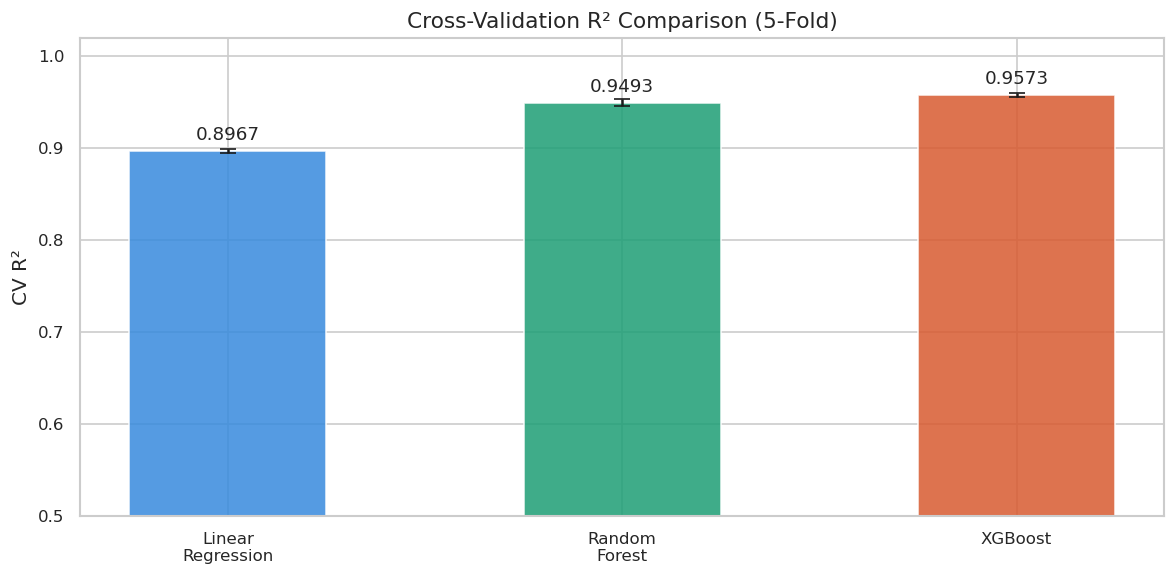

In [23]:
# 6.1 各模型 CV R² 对比图 
rf_std = grid_rf.cv_results_['std_test_score'][grid_rf.best_index_]
gb_std = grid_xgb.cv_results_['std_test_score'][grid_xgb.best_index_]

model_labels = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
means      = [scores_lr.mean(), grid_rf.best_score_,  grid_xgb.best_score_]
stds       = [scores_lr.std(),  rf_std,               gb_std]
bar_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]

fig, ax = plt.subplots()
bars = ax.bar(model_labels, means, yerr=stds, capsize=5,
              color=bar_colors, alpha=0.85, width=0.5)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('CV R²')
ax.set_title('Cross-Validation R² Comparison (5-Fold)')
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.008, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_r2_comparison.png')
plt.show()

In [24]:
# 6.2 测试集评估
pipe_lr.fit(X_lr_train, y_train_log)

X_lr_test = get_X(X_test, LR_NUM, LR_CAT)
X_rf_test = get_X(X_test, RF_NUM, RF_CAT)
X_xgb_test = get_X(X_test, GB_NUM, GB_CAT)

# 预测（线性回归还原）
pred_lr = np.exp(pipe_lr.predict(X_lr_test))
pred_rf = grid_rf.best_estimator_.predict(X_rf_test)
pred_xgb = grid_xgb.best_estimator_.predict(X_xgb_test)

# 指标汇总:MAE、MSE、RMSE、R²、Adjusted R²、MAPE
def adjusted_r2(r2, n, k):
    """adjusted R² = 1 - (1-R²)*(n-1)/(n-k-1)"""
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

n_test = len(y_test_raw)

def get_n_features(pipeline, cat_key='cat'):
    n_num = len(pipeline.named_steps['pre'].transformers_[0][2])
    try:
        n_cat = len(pipeline.named_steps['pre']
                    .named_transformers_[cat_key]
                    .get_feature_names_out())
    except Exception:
        n_cat = 0
    return n_num + n_cat

k_lr  = get_n_features(pipe_lr)
k_rf  = get_n_features(grid_rf.best_estimator_)
k_xgb = get_n_features(grid_xgb.best_estimator_)

results = {}
for name, pred, k in [
    ('Linear Regression', pred_lr,  k_lr),
    ('Random Forest',     pred_rf,  k_rf),
    ('XGBoost',           pred_xgb, k_xgb),
]:
    r2   = r2_score(y_test_raw, pred)
    mse  = mean_squared_error(y_test_raw, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_raw, pred)
    mpe  = mape(y_test_raw, pred)
    adj  = adjusted_r2(r2, n_test, k)
    results[name] = dict(R2=r2, Adj_R2=adj, MSE=mse, RMSE=rmse, MAE=mae, MAPE=mpe)

print(f"\n{'模型':<22} {'R²':>7} {'Adj R²':>8} {'MSE':>14} {'RMSE':>10} {'MAE':>10} {'MAPE':>7}")
print('-' * 82)
for name, m in results.items():
    print(f"{name:<22} {m['R2']:>7.4f} {m['Adj_R2']:>8.4f} "
          f"{m['MSE']:>14,.0f} {m['RMSE']:>10,.0f} {m['MAE']:>10,.0f} {m['MAPE']:>6.2f}%")


模型                          R²   Adj R²            MSE       RMSE        MAE    MAPE
----------------------------------------------------------------------------------
Linear Regression       0.8923   0.8916  4,522,812,595     67,252     49,773   7.56%
Random Forest           0.9550   0.9545  1,888,517,039     43,457     29,197   4.40%
XGBoost                 0.9627   0.9622  1,567,633,399     39,593     27,714   4.19%


In [25]:
# 6.3 过拟合检验：CV R² vs 测试集 R² 对比
print(f"\n{'模型':<25}  {'CV R²':>8}  {'测试R²':>8}  {'差值':>8}  {'判断':>10}")
print('-' * 68)

test_scores = [
    results['Linear Regression']['R2'], 
    results['Random Forest']['R2'], 
    results['XGBoost']['R2']
]

cv_scores   = [scores_lr.mean(), grid_rf.best_score_,  grid_xgb.best_score_]
names_list  = ['Linear Regression', 'Random Forest', 'XGBoost']

for name, cv_r2, test_r2 in zip(names_list, cv_scores, test_scores):
    diff   = cv_r2 - test_r2
    status = '正常' if abs(diff) < 0.05 else '疑似过拟合' if diff > 0 else '测试集更优'
    print(f"{name:<25}  {cv_r2:>8.4f}  {test_r2:>8.4f}  {diff:>+8.4f}  {status:>10}")


模型                            CV R²      测试R²        差值          判断
--------------------------------------------------------------------
Linear Regression            0.8967    0.8923   +0.0045          正常
Random Forest                0.9493    0.9550   -0.0057          正常
XGBoost                      0.9573    0.9627   -0.0054          正常


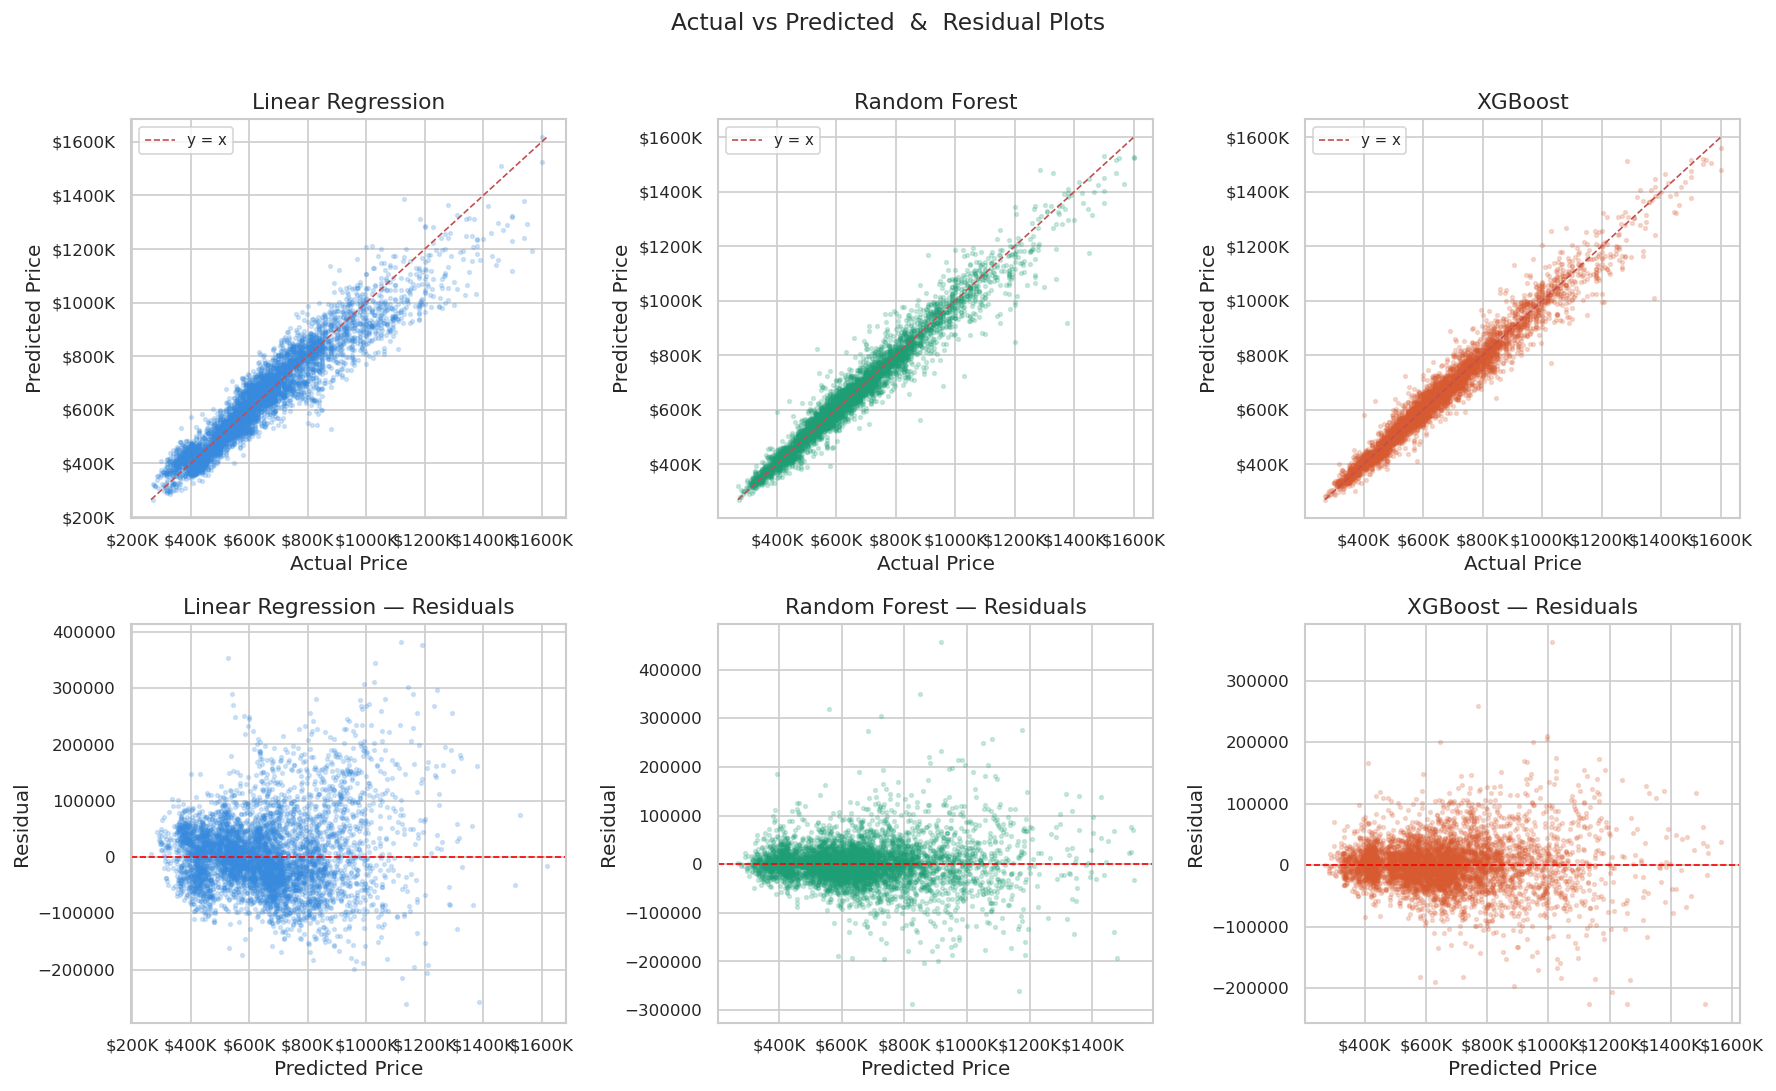

In [26]:
# 6.4 实际 vs 预测 + 残差图
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
preds_list = [pred_lr,             pred_rf,         pred_xgb]   
names      = ['Linear Regression', 'Random Forest', 'XGBoost']
bar_colors = [COLORS['primary'],   COLORS['secondary'], COLORS['accent']]

for j, (pred, name, c) in enumerate(zip(preds_list, names, bar_colors)):
    ax = axes[0][j]
    ax.scatter(y_test_raw, pred, alpha=0.2, s=5, color=c)
    mn, mx = min(y_test_raw.min(), pred.min()), max(y_test_raw.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1, label='y = x')
    ax.set_title(name)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.xaxis.set_major_formatter(price_formatter)
    ax.yaxis.set_major_formatter(price_formatter)
    ax.legend(fontsize=9)

    ax2 = axes[1][j]
    resid = y_test_raw.values - pred
    ax2.scatter(pred, resid, alpha=0.2, s=5, color=c)
    ax2.axhline(0, color='red', linestyle='--', lw=1)
    ax2.set_title(f'{name} — Residuals')
    ax2.set_xlabel('Predicted Price')
    ax2.set_ylabel('Residual')
    ax2.xaxis.set_major_formatter(price_formatter)

plt.suptitle('Actual vs Predicted  &  Residual Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_pred_residuals.png')
plt.show()

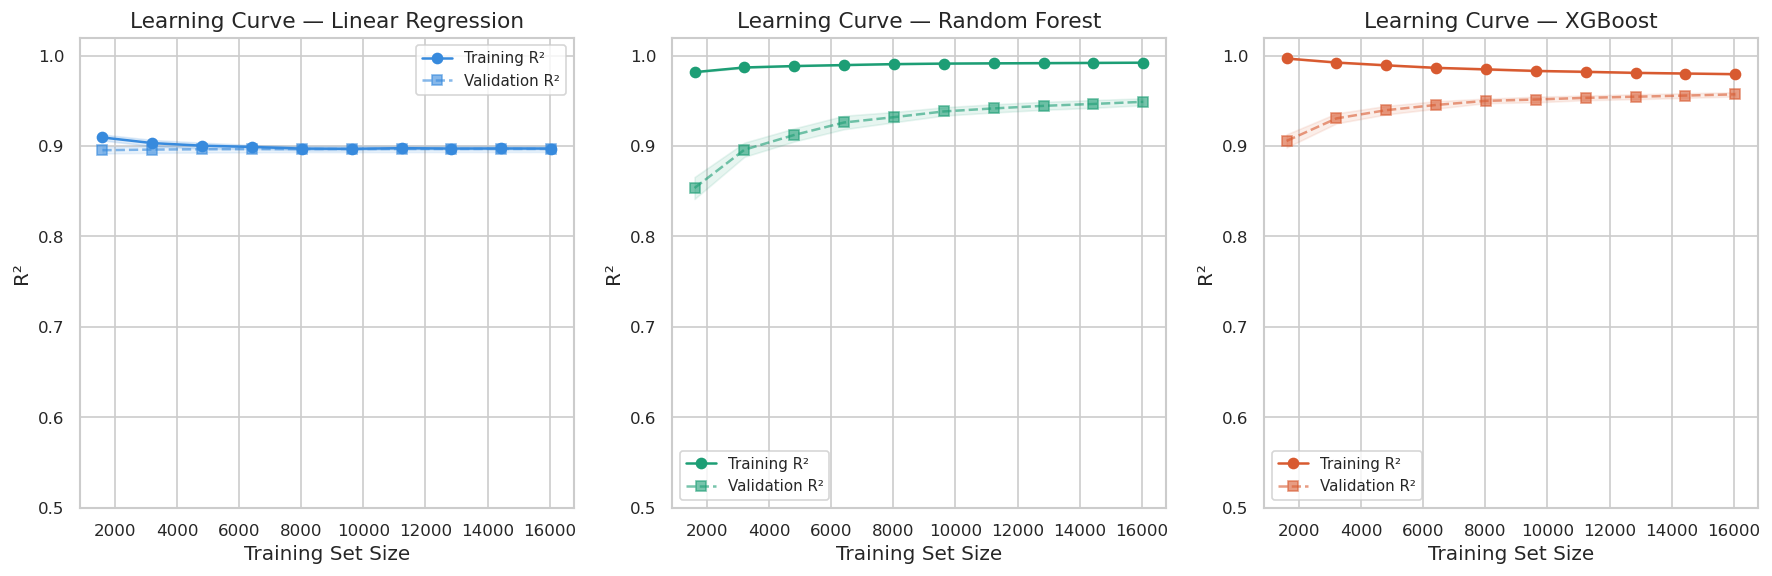

In [27]:
# 6.5 学习曲线（拟合度曲线）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_configs = [
    ('Linear Regression', pipe_lr,                 X_lr_train,  y_train_log, COLORS['primary']),
    ('Random Forest',     grid_rf.best_estimator_, X_rf_train,  y_train_raw,     COLORS['secondary']),
    ('XGBoost',           grid_xgb.best_estimator_,X_xgb_train,  y_train_raw,     COLORS['accent']),
]

for ax, (name, model, X_tr, y_tr, color) in zip(axes, model_configs):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_tr,
        cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color, label='Training R²')
    ax.fill_between(train_sizes, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color=color)
    ax.plot(train_sizes, val_mean, 's--', color=color, alpha=0.6, label='Validation R²')
    ax.fill_between(train_sizes, val_mean - val_std,
                    val_mean + val_std, alpha=0.1, color=color)
    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R²')
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.02)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png')
plt.show()

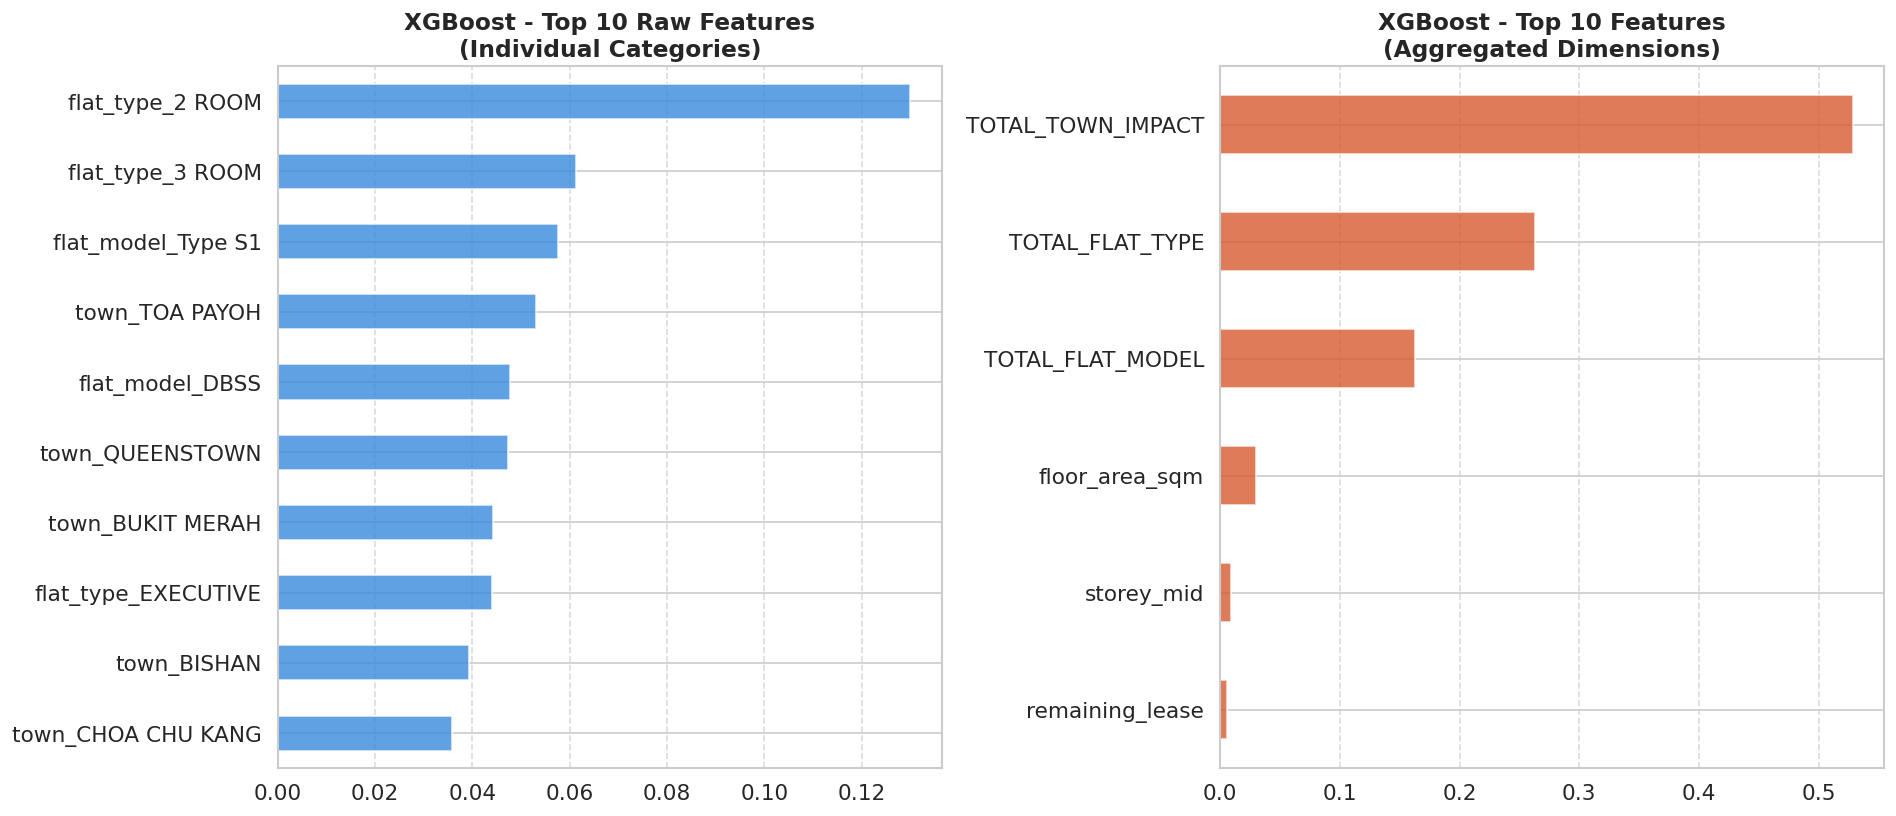

In [28]:
# 6.7 提取 XGBoost 特征重要性
# 计算原始 Top 10
best_xgb = grid_xgb.best_estimator_
xgb_feat_names = GB_NUM + list(best_xgb.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(GB_CAT))
xgb_imp = pd.Series(best_xgb.named_steps['model'].feature_importances_, index=xgb_feat_names).sort_values(ascending=False)

xgb_top10_raw = xgb_imp.head(10).sort_values(ascending=True)

# 维度聚合计算 (汇总地段、房型等整体影响力) 
xgb_agg = xgb_imp.copy()

# 定义需要聚合的维度前缀
categories = {
    'town_': 'TOTAL_TOWN_IMPACT',
    'flat_model_': 'TOTAL_FLAT_MODEL',
    'flat_type_': 'TOTAL_FLAT_TYPE'
}

agg_results = {}
for prefix, new_label in categories.items():
    mask = xgb_agg.index.str.startswith(prefix)
    agg_results[new_label] = xgb_agg[mask].sum()
    xgb_agg = xgb_agg[~mask] 

xgb_final = pd.concat([xgb_agg, pd.Series(agg_results)])
xgb_top10_agg = xgb_final.sort_values(ascending=False).head(10).sort_values(ascending=True)

# 绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 子图 1: 原始细分特征 Top 10
ax1.tick_params(axis='both', labelsize=13) 
xgb_top10_raw.plot(kind='barh', ax=ax1, color=COLORS['primary'], alpha=0.8)
ax1.set_title('XGBoost - Top 10 Raw Features\n(Individual Categories)',fontsize=14,fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# 子图 2: 维度聚合后 Top 10
ax2.tick_params(axis='both', labelsize=13) 
xgb_top10_agg.plot(kind='barh', ax=ax2, color=COLORS['accent'], alpha=0.8)
ax2.set_title('XGBoost - Top 10 Features\n(Aggregated Dimensions)',fontsize=14,fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_feature_comparison.png')
plt.show()

### 7.购房建议

In [29]:
# 基于 XGBoost 模型的购房建议
best_xgb_pipeline = grid_xgb.best_estimator_
model_filename = "xgboost_housing_pipeline.pkl"
joblib.dump(best_xgb_pipeline, model_filename)
print(f"模型已成功保存至: {model_filename}")

def generate_buying_advice(df, xgb_imp, best_xgb_pipeline, GB_NUM, GB_CAT):
    print("=" * 65)
    print("基于 XGBoost 模型的新加坡组屋购房建议")
    print("=" * 65)

    # ── 基准行（中位数参数，用于控制变量对比） ──────────────────
    base = {
        'floor_area_sqm' : float(df['floor_area_sqm'].median()),
        'storey_mid'     : float(df['storey_mid'].median()),
        'remaining_lease': float(df['remaining_lease'].median()),
        'flat_type'      : '4 ROOM',
        'town'           : 'TAMPINES',
        'flat_model'     : 'Model A',
    }

    def predict_price(**overrides):
        row = {**base, **overrides}
        X_tmp = pd.DataFrame([row])[GB_NUM + GB_CAT]
        return float(best_xgb_pipeline.predict(X_tmp)[0])

    # ── 1. 刚需/保值型建议：房型选择 ──
    p_2room = predict_price(flat_type='2 ROOM')
    p_4room = predict_price(flat_type='4 ROOM')
    p_5room = predict_price(flat_type='5 ROOM')
    p_exec  = predict_price(flat_type='EXECUTIVE')

    print(f'\nØ 保值/刚需型建议—— 选对房型是关键')
    print(f"  根据 XGBoost 特征重要性，房型（Flat Type）是仅次于地段的最强价格驱动因素，")
    print(f"  利用梯度提升树计算不同房型对价格的具体影响得出：")
    print(f"    • 2 ROOM  → 预测价 ${p_2room:,.0f}")
    print(f"    • 4 ROOM  → 预测价 ${p_4room:,.0f}  （基准）")
    print(f"    • 5 ROOM  → 预测价 ${p_5room:,.0f}  （+{(p_5room-p_4room)/p_4room*100:.1f}% vs 4房）")
    print(f"    • EXECUTIVE → 预测价 ${p_exec:,.0f}  （+{(p_exec-p_4room)/p_4room*100:.1f}% vs 4房）")
    print(f' "大房型"才是保值核心！建议刚需家庭优先锁定 4 房或 5 房')
    print(f"  在总价可控的前提下尽量选择更大房型，抗跌性与转售流动性均更强。")

    # ── 2. 投资型建议：核心地段 + 稀缺户型 ──
    premium_models = ['DBSS', 'Type S1', 'Type S2']
    prem_mask = df['flat_model'].isin(premium_models)
    if prem_mask.sum() > 10:
        premium_price = df[prem_mask]['resale_price'].median()
        normal_price  = df[~prem_mask]['resale_price'].median()
        prem_pct = (premium_price - normal_price) / normal_price * 100
    else:
        prem_pct = float('nan')

    top_towns = ['BUKIT TIMAH', 'QUEENSTOWN', 'BISHAN', 'TOA PAYOH', 'BUKIT MERAH']
    mid_town  = 'TAMPINES'
    p_mid = predict_price(town=mid_town)

    print(f'\nØ 投资型建议—— 关注核心地段与稀缺户型')
    print(f"  XGBoost 聚合维度中，地段（Town）重要性高达 ~52%，户型（Flat Model）~16%，")
    print(f"  利用梯度提升树通过非线性学习捕捉地段和稀缺性溢价得出：")
    print(f"  地段影响（控制其他变量，对比基准 {mid_town}）：")
    for t in top_towns:
        try:
            p_t = predict_price(town=t)
            print(f"    • {t:<20} 预测价 ${p_t:,.0f}  (+{(p_t-p_mid)/p_mid*100:.1f}%)")
        except Exception:
            pass
    if not np.isnan(prem_pct):
        print(f"  稀缺户型溢价：DBSS / Type S1 较普通户型溢价 {prem_pct:.1f}%")
    print(f"  若预算充裕，优先考虑 Bukit Timah、Queenstown、Bishan 等核心地段，")
    print(f"  或 DBSS 等稀缺户型，长期资产保值性更强。")

    # ── 3. 性价比型建议：价值洼地地区 + 中低楼层 ────────────────
    town_median     = df.groupby('town')['resale_price'].median()
    all_town_median = town_median.mean()
    value_towns     = town_median[town_median < all_town_median].sort_values().head(5)

    p_high_fl = predict_price(storey_mid=20.0)
    p_low_fl  = predict_price(storey_mid=8.0)

    print(f'\nØ 性价比型建议—— 寻找价值洼地')
    print(f"  避开梯度提升树模型中的高权重热门区域，选取中等地段降低总价，")
    print(f"  选择中低楼层，就可以买大面积房屋，综合以上得出：")
    print(f"  高性价比地区（中位价低于全岛均值 ${all_town_median:,.0f}）：")
    for t, p_raw in value_towns.items():
        try:
            p_ctrl = predict_price(town=t)
            print(f"    • {t:<25} 原始中位价 ${p_raw:,.0f}  模型预测（控制变量）${p_ctrl:,.0f}")
        except Exception:
            print(f"    • {t:<25} 原始中位价 ${p_raw:,.0f}")
    print(f"  楼层节省（XGBoost 捕捉楼层非线性效应）：")
    print(f"    高楼层(20层) ${p_high_fl:,.0f}  vs  中楼层(8层) ${p_low_fl:,.0f}")
    print(f"    楼层节省幅度：{(p_high_fl - p_low_fl)/p_high_fl*100:.1f}%")
    print(f"  在 Yishun、Woodlands、Bedok 等地选择中楼层的 4 房或 5 房，")
    print(f"  可以在预算有限的情况下获得最大居住空间，极大提升居住品质。")

    print("\n" + "=" * 65)
    print("注：所有预测均基于性能最优的 XGBoost 模型（三模型对比后确定），")
    print("    控制变量条件下的预测结果仅供参考，实际成交价受个体房源因素影响。")
    print("=" * 65)


# ── 运行建议引擎 ─────────────────────────────────────────────
generate_buying_advice(
    df                = df_2025,
    xgb_imp           = xgb_imp,
    best_xgb_pipeline = grid_xgb.best_estimator_,
    GB_NUM            = GB_NUM,
    GB_CAT            = GB_CAT
)


模型已成功保存至: xgboost_housing_pipeline.pkl
基于 XGBoost 模型的新加坡组屋购房建议

Ø 保值/刚需型建议—— 选对房型是关键
  根据 XGBoost 特征重要性，房型（Flat Type）是仅次于地段的最强价格驱动因素，
  利用梯度提升树计算不同房型对价格的具体影响得出：
    • 2 ROOM  → 预测价 $628,554
    • 4 ROOM  → 预测价 $654,129  （基准）
    • 5 ROOM  → 预测价 $683,553  （+4.5% vs 4房）
    • EXECUTIVE → 预测价 $729,684  （+11.6% vs 4房）
 "大房型"才是保值核心！建议刚需家庭优先锁定 4 房或 5 房
  在总价可控的前提下尽量选择更大房型，抗跌性与转售流动性均更强。

Ø 投资型建议—— 关注核心地段与稀缺户型
  XGBoost 聚合维度中，地段（Town）重要性高达 ~52%，户型（Flat Model）~16%，
  利用梯度提升树通过非线性学习捕捉地段和稀缺性溢价得出：
  地段影响（控制其他变量，对比基准 TAMPINES）：
    • BUKIT TIMAH          预测价 $844,696  (+29.1%)
    • QUEENSTOWN           预测价 $913,183  (+39.6%)
    • BISHAN               预测价 $786,108  (+20.2%)
    • TOA PAYOH            预测价 $779,758  (+19.2%)
    • BUKIT MERAH          预测价 $819,475  (+25.3%)
  稀缺户型溢价：DBSS / Type S1 较普通户型溢价 56.9%
  若预算充裕，优先考虑 Bukit Timah、Queenstown、Bishan 等核心地段，
  或 DBSS 等稀缺户型，长期资产保值性更强。

Ø 性价比型建议—— 寻找价值洼地
  避开梯度提升树模型中的高权重热门区域，选取中等地段降低总价，
  选择中低楼层，就可以买大面积房屋，综合以上得出：
  高性价比地区（中位价低于全岛均值 $652,281）：
    • 